<a href="https://colab.research.google.com/github/xyLau-xyLau/ci-cd-pruebas/blob/main/tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Genómica Computacional: Tarea 1
## Ernesto Cárdenas Torres

---

## 1. Expresiones regulares.
### Ejercicio 1.

r'TATAG\[^AT](T*|AC)TATA'

#### a) TATACGCGTATAGAACTATAGCCCTATA

Posibilidades:

- TATACGCG**TATAG**AACTATAGCCCTATA - Sin embargo falla porque después de TATAG contiene A.

- TATACGCGTATAGAAC**TATAGC**CTATA - En este caso tenemos que cumple TATAG seguido de una C la cual es vaĺida porque no es A ni T. Sin embargo falla ya que podemos tener cero o más T o AC. En este caso tenemos una C pero sin la A anterior.

Por lo tanto la cadena a) no contiene instancias de la expresión propuesta.

#### b) TATAGCGTATAGGACTATAGTATA

Posibilidades:

- **TATAGC**GTATAGGACTATAGTATA - En este caso tenemos una letra G antes de TATA la cual no puede ser producida por la regex.

- TATAGCG**TATAGGACTATA**GTATA - Esta cadena si contiene la regex propuesta. Contiene TATAG seguido de G que cumple con \[^AT] seguido de AC que cumple con (T* | AC) y termina con TATA. La posición es \[7,18].

#### c) GTATGTATAGCCGACTTA

Posibilidades:

- GTATG**TATAGC**CGACTTA - Esta cadena no contiene TATA después de TATAG.

Por lo tanto la cadena c) no contiene instancias de la expresión.

#### d) TATAGCCGACTATA

Posibilidades:

- **TATAGC**CGACTATA - Esta cadena le falta una A antes de la C y le sobra la subcadena GAC.

Por lo tanto la cadena d) no contiene instancias de la expresión.

---





In [34]:
import re

secs = ['ATATATACATACTGGTAATGGGCGCGCGTGTGTTAAGTTCTGTTGTAGGGGTGATTAGGGGCG',
        'GGCCCACACCCCACACCAATATATGTGGTGTGGGCTCCACTCTCTCGCGCTCGCGCTGGGGAT',
        'ATAAGGTGTGTGGGCGCGCCCCGCGCGCGCGTTTTTTCGCGCGCCCCCGCGCGCGCGCGCGCG',
        'GGCGCGGGACGCGGCGGCGGATCCCGATCCGTGCGTCAATACTATTATGGCCAGATAGAATAA',
        'GTGCTGCTGCGGCGCCCACACCTATTATCTCTCTCTCTCTGCCTCTCCACCTCGGGGCTTAAT',
        'GCGCTGCTGCTGGCTCGATGGGCGCGTGCGTCGTAGCTCGATGCTGGCTCGAGCTGTAATCTT',
        'GGCGCTCGCTCGGATGCGCGGCCGGGCTCTCTGCTCGCGCTCGCTTCGCGCTCGTGACCGCTG',
        'AATTGGTGCGCGCTCGCGCACACACAGAGAGAGGGTTTATATAGGATGATATATCCACATTGG',
        'ATGCTGCTGCTGGCTCTGCTTGCGCTCTGCTCGCTGGGGTGTGTGTGCCGCGCGCTGCTGCTC',
        'GCTGGGCTCGCTCGATGCGCGCGGGCGCGCGACCGCGGACGGCGTCGCTGCTAAATGGGCTTC']
patron_valido = r'ATG((A[ACG][ATCG])|([CG][TACG][TACG])|(TG[TCG])|'
patron_valido += r'(TA[TC])|(T[TC][TACG]))+(T(GA|A(G|A)))'
lista_coincidencias = []
for i in range(10):
  if re.search(patron_valido, secs[i]):
    lista_coincidencias.append(i + 1)
print("Ejercicio 2. Las secuencias con regiones codificadoras válidas son:")
print(lista_coincidencias)

Ejercicio 2. Las secuencias con regiones codificadoras válidas son:
[4, 6]


### Ejercicio 3.

Cadena: TATAATCGTATTGTACTAATATTGTATATATA

Posición de Patrones

Comenzamos leyendo la cadena y como no encontramos estados con TATA nos desplazamos para buscar en el resto de la cadena.

A continuación mostramos todas las apariciones.

- TATA $\Phi$ ATCGTATTGTACTAATATTGTATATATA : \{}
  - $\Phi$ATCGTATTGTACTAATATTGTAATATAT$\Phi$ : \{ATC, GTA, ATT, CTA, ATAT}
    - ATC
      - **ATC**GTATTGTACTAATATTGTAATATAT
    - GTA
      - ATC**GTA**TTGTACTAATATTGTAATATAT
      - ATCGTATT**GTA**CTAATATTGTAATATAT
      - ATCGTATTGTACTAATATT**GTA**ATATAT
    - ATT
      - ATCGT**ATT**GTACTAATATTGTAATATAT
      - ATCGTATTGTACTAAT**ATT**GTAATATAT
    - CTA
      - ATCGTATTGTA**CTA**ATATTGTAATATAT
    - ATAT
      - ATCGTATTGTACTA**ATAT**TGTAATATAT
      - ATCGTATTGTACTAATATTGTA**ATAT**AT
      - ATCGTATTGTACTAATATTGTAAT**ATAT**

Terminamos la ejecución descartando la A al final ya que no llega a un estado con un término buscado.

- TATAATCGTATTGTACTAATATTGTATATATA$\Phi$ : \{}

Patrones encontrados: \{ATC, GTA, ATT, CTA, ATAT}
#### Autómata

Los terminales para cada patrón son los estados con una arista incidente etiquetada con un *.

Se agregan transiciones hacia los sufijos \{A, C, AT} y para error hacia la raíz.

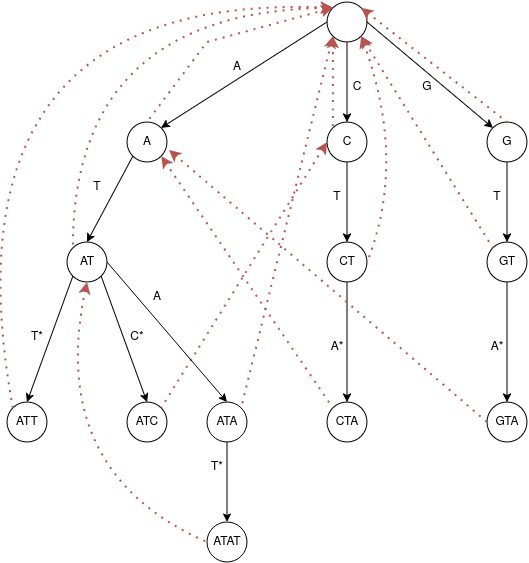

## 2. Alineamientos

### Ejercicio 1. Obtén los alineamientos globales para las secuencias

Matriz de score:

|-|-|C|T|T|A|G|A|
|---|---|---|---|---|---|---|---|
|-|0|-2|-4|-6|-8|-10|-12|
|G|-2|-1|-3|-5|-7|-6|-8|
|T|-4|-3|1|-1|-3|-5|-7|
|A|-6|-5|-1|0|1|-1|-3|
|A|-8|-7|-3|-2|2|0|1|

Matriz de flechas:

|-|-|C|T|T|A|G|A|
|---|---|---|---|---|---|---|---|
|-|:D|$\leftarrow$|$\leftarrow$|$\leftarrow$|$\leftarrow$|$\leftarrow$|$\leftarrow$|
|G|$\uparrow$|$\nwarrow$|$\leftarrow\nwarrow$|$\leftarrow\nwarrow$|$\leftarrow\nwarrow$|$\nwarrow$|$\leftarrow$|
|T|$\uparrow$|$\leftarrow\nwarrow$|$\nwarrow$|$\leftarrow\nwarrow$|$\leftarrow$|$\leftarrow$|$\leftarrow\nwarrow$|
|A|$\uparrow$|$\nwarrow\uparrow$|$\uparrow$|$\nwarrow$|$\nwarrow$|$\leftarrow$|$\leftarrow$|
|A|$\uparrow$|$\uparrow\nwarrow$|$\uparrow$|$\uparrow\nwarrow$|$\nwarrow$|$\leftarrow\nwarrow$|$\nwarrow$|

Encontramos 3 posibles alineamientos que se reconstruyen a continuación:

|C|T|T|A|G|A|
|---|---|---|---|---|---|
|G|-|T|A|-|A|
|G|T|-|A|-|A|
|-|G|T|A|-|A|

### Ejercicio 2. Realiza el siguiente alineamiento local con SW.


|:D|-|A|G|C|G|T|A|G|
|---|---|---|---|---|---|---|---|---|
|-|0|0|0|0|0|0|0|0|
|C|0|0|10|10|10|3|0|10|
|T|0|10|3|5|5|20|13|6|
|C|0|3|20|13|15|13|15|23|
|G|0|0|13|30|23|16|9|25|
|T|0|10|6|23|25|33|26|19|
|T|0|10|5|16|18|35|43|36|
|C|0|3|20|15|26|28|36|53|

Alineamientos:

|A|G|C|G|T|A|G|
|---|---|---|---|---|---|---|
|T|-|C|G|T|T|C|
|10|3|13|23|33|43|53|

|A|-|C|G|T|A|G|
|---|---|---|---|---|---|---|
|C|T|C|G|T|T|C|
|10|3|13|23|33|43|53|

|A|G|-|G|T|A|G|
|---|---|---|---|---|---|---|
|C|T|C|G|T|T|C|
|10|20|13|23|33|43|53|

|A|G|C|-|T|A|G|
|---|---|---|---|---|---|---|
|C|T|C|G|T|T|C|
|10|20|30|23|33|43|53|

In [35]:
import numpy as np
import matplotlib.pyplot as plt


def delta(u, v, msm = -2, mth = 2):
  if u == v:
    return mth
  return msm

def direccion (l) :
  mx = max(l)
  idxs = [i for i, j in enumerate(l) if j == mx]
  if (len(idxs) == 1):
    cod = idxs[0] + 1
  else:
    cod = sum([i + 1 for i in idxs])
  assert cod > 0, f"Error para {l}"
  return mx, cod

def entrada(S, i, j, V, U, mu = -1, eps = 2, sigma = -2 , delta = delta):
  arriba = S[i - 1, j] + sigma
  izquierda = S[i , j - 1] + sigma
  u, v = V[i - 1] , U[j - 1]
  valdelta = delta(u ,v , msm = mu, mth = eps)
  match = S[i - 1, j - 1] + valdelta
  l = [arriba, izquierda, match]
  return direccion(l) ## valor de donde viene el maximo



def alinea(V, U):
    S = np.zeros((len(V) + 1 ,len(U) + 1)) #score
    B = np.zeros_like(S) #direcciones
    for i in range (1, len(V) + 1):
        S[i, 0] = S[i - 1, 0] - eps
        B[i, 0] = 1
    for j in range (1, len(U) + 1):
        S[0, j] = S[0, j - 1] - eps
        B[0, j] = 2
    for i in range (1, len(V) + 1):
        for j in range (1, len(U) + 1):
            S[i, j], B[i, j] = entrada(S, i, j, V, U)
    return S, B


def imprime_alineamiento(U, V, B):
  j = len(U)
  i = len(V)
  u_alineada = ''
  v_alineada = ''
  bandera = True
  while bandera:
    match B[i][j]:
      case 1:
        v_alineada = V[i - 1] + v_alineada
        u_alineada = '-' + u_alineada
        i -= 1
      case 2:
        v_alineada = '-' + v_alineada
        u_alineada = U[j - 1] + u_alineada
        j -= 1
      case _:
        u_alineada = U[j - 1] + u_alineada
        v_alineada = V[i - 1] + v_alineada
        i -= 1
        j -= 1
    if i == 0 and j == 0:
      bandera = False
  print(v_alineada)
  print(u_alineada)

def muta(sec, p = 0):
  sec_final = ''
  opciones = list('ACGT')
  for c in sec:
    if (np.random.random() <= p):
      opciones.remove(c)
      sec_final += np.random.choice(opciones)
      opciones.append(c)
    else:
      sec_final += c
  return sec_final

def genera_secuencia(longitud = 1000):
  sec = ''
  opciones = list('ACGT')
  for _ in range(longitud):
    sec += np.random.choice(opciones)
  return sec

mu = -1
eps = 2
sigma = -2
V = 'ATCGTAC' #|V| = n filas
U = 'ATGTTAT' #|U| = m columnas
S, B = alinea(V, U)
print("a) El mejor alineamiento es el siguiente:")
imprime_alineamiento(U, V, B)

a) El mejor alineamiento es el siguiente:
ATCGTAC
ATGTTAT


b) Scores vs Probabilidad de Mutación(Media)
Experimentos: 50
Tamaño de secuencia: 500


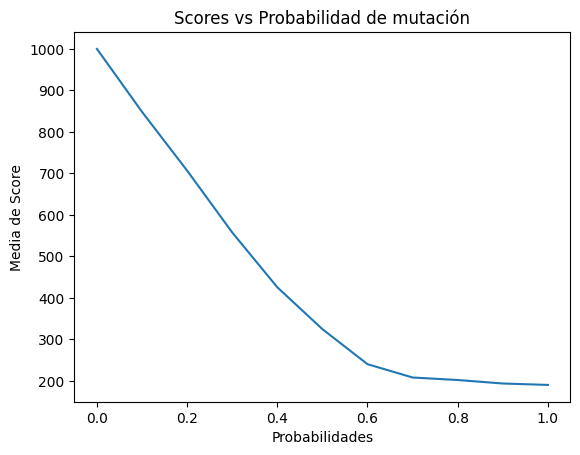

In [36]:
probabilidades = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
media = []
scores = []

print("b) Scores vs Probabilidad de Mutación(Media)")
print("Experimentos: 50")
print("Tamaño de secuencia: 500")
for probabilidad in probabilidades:
  for y in range(0, 50):
    U = genera_secuencia(500)
    V = muta(U, probabilidad)
    S, B = alinea(V, U)
    scores.append(S[500][500])
  media.append(np.mean(np.array(scores)))
  scores = []

plt.plot(np.array(probabilidades), np.array(media))
plt.xlabel('Probabilidades')
plt.ylabel('Media de Score')
plt.title('Scores vs Probabilidad de mutación')
plt.show()

## 3. Computación y complejidad

### Ejercicio 1. Algoritmo Misterio

Respuesta: El algoritmo estima el valor de $\pi$ mediante probabilidad usando el método Monte Carlo.


In [37]:
def misterio(iteraciones = 1000000):
  rng = np.random.default_rng()
  i = 1
  D = 0
  while i < iteraciones:
    i += 1
    x = rng.uniform(-1, 1)
    y = rng.uniform(-1, 1)
    d = np.sqrt(np.square(x) + np.square(y))
    if d <= 1:
      D += 1
  x = 4 * (D / i)
  return x

print("Estimación con 1,000,000 de iteraciones:")
print(misterio())


Estimación con 1,000,000 de iteraciones:
3.14118


### Ejercicio 2. Determina la complejidad del algoritmo raro.

- El primer *for* corre de $1$ a $n$ por lo tanto tenemos n verificaciones que determinan si el número es impar. Vamos a verificar ahora la complejidad de los for internos en función de $n$.

- Dado que en una secuencia de $1$ a $n$ tenemos a lo más $ceiling(\frac{n}{2})$ números impares, el segundo *for* corre de $1$ a $n$ $ceiling(\frac{n}{2})$ veces. Es decir tenemos una complejidad aproximada de $O (n * ceiling(\frac{n}{2}))$ la cual es dominada por $O(n^2)$.

- Para el tercer *for* tenemos que iteramos de 1 a i, siendo i un número impar.
  Si sumamos los primeros $ceiling(\frac{n}{2})$ impares tenemos una complejidad aproximada de $O(ceiling(\frac{n}{2})^2)$ la cual también es dominada por $O(n^2)$.

- Ambos *for* no son anidados entre ellos, por lo tanto las funciones que los acotan se pueden sumar y dicha suma quedará acotada también por $n^2$ multiplicado por un escalar, lo que nos permite concluir que el *algoritmo raro* pertenece a $O(n^2)$.



In [38]:
print("Ejercicio 3")

import random

def muta_cadena(cadena = '0'):
  posicion = random.randint(0, len(cadena) - 1)
  cadena = list(cadena)
  if cadena[posicion] == '0':
    cadena[posicion] = '1'
  else:
    cadena[posicion] = '0'
  return "".join(cadena)

def expansion_modificacion(semilla = '0', p = 0.5):
  rng = np.random.default_rng()
  num_aleatorio = rng.uniform(0,1)
  if num_aleatorio <= p:
    return muta_cadena(semilla)
  semilla += semilla
  return semilla

def itera_n_veces(semilla = '0', p = 0.5, iteraciones = 5):
  if iteraciones == 0:
    return semilla
  else:
    return itera_n_veces(expansion_modificacion(semilla, p), p, iteraciones - 1)

print("Cadena: 0. Probabilidad: 0.25. Iteraciones: 5")
print(f"Experimento #1: {itera_n_veces('0', 0.25, 5)}")
print(f"Experimento #2: {itera_n_veces('0', 0.25, 5)}")
print(f"Experimento #3: {itera_n_veces('0', 0.25, 5)}")

Ejercicio 3
Cadena: 0. Probabilidad: 0.25. Iteraciones: 5
Experimento #1: 0100010001000100
Experimento #2: 0100010001000100
Experimento #3: 0010000000100000


## 4. Probabilidad y estadística

Ejercicio 1.a


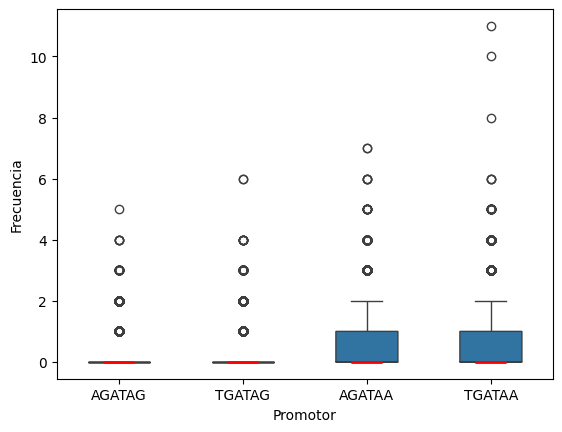

In [39]:
import pandas as pd
import seaborn as sns

print("Ejercicio 1.a")

promotores = ['AGATAG', 'TGATAG', 'AGATAA', 'TGATAA']
apariciones_totales = {}
for promotor in promotores:
  apariciones_totales[promotor] = []

with open('/promotores.txt', 'r', encoding='utf-8') as file:
  for secuencia in file:
    for promotor in promotores:
      apariciones_totales[promotor].append(secuencia.count(promotor))

df_long = pd.DataFrame([(k, v) for k, l in apariciones_totales.items() for v in l],
                       columns=['Promotor', 'Frecuencia'])

sns.boxplot(
  x='Promotor',
  y='Frecuencia',
  patch_artist=True,
  width=.5,
  notch = True,
  data = df_long,
  medianprops={"color":"r", "linewidth":2}
  )
plt.show()

In [40]:
print("Ejercicio 1.b")

for promotor in apariciones_totales:
  print(f"{promotor}: Media = {np.mean(apariciones_totales[promotor])}")
  print(f"{promotor}: Desviación Estándar = {np.std(apariciones_totales[promotor])}")

Ejercicio 1.b
AGATAG: Media = 0.18453538513570644
AGATAG: Desviación Estándar = 0.4388497692545206
TGATAG: Media = 0.22846030269721823
TGATAG: Desviación Estándar = 0.4931851689779564
AGATAA: Media = 0.4821171894816944
AGATAA: Desviación Estándar = 0.7340057927064843
TGATAA: Media = 0.6139342183140273
TGATAA: Desviación Estándar = 0.8284502958464521


### Ejercicio 2.

Datos:

$S = 0.93$

$E = 0.99$

$Prev = \frac{16000}{120000000} ≈  0.00013$

$Pos = ? $

$Neg = ? $


$ 😀 = $

2.a)

